# Centralidades de Hubs y Autoridad

Se genera una red de las 30 empresas con mayor capitalizacion de mercado que cotizan en el S&P500.

- Nodos: 30 tickers con mayor market cap del S&P 500.
- Aristas dirigidas: $u\to v$ significa “$u$ provee a $v$”.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display
import matplotlib
from matplotlib import colors as mcolors

pio.renderers.default = "vscode"
plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

In [2]:
from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH"
]

E: List[Tuple[str, str]] = [
    # semiconductores / hardware / computo
    ("MU", "NVDA"),
    ("AVGO", "AAPL"),

    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),

    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),

    # nube / servicios
    ("AMZN", "NFLX"),
    ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"),
    ("AMZN", "PLTR"),

    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"),
    ("MSFT", "PLTR"),

    ("GOOGL", "PLTR"),
    ("ORCL", "PLTR"),

    # retail
    ("AAPL", "WMT"), ("AAPL", "COST"),
    ("PG", "WMT"),
    ("BRK.B", "WMT"),

    # pagos / tarjetas
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),

    # farmacia
    ("LLY", "AMZN"),
]

In [3]:
G1 = nx.DiGraph()
G1.add_nodes_from(V)
G1.add_edges_from(E)

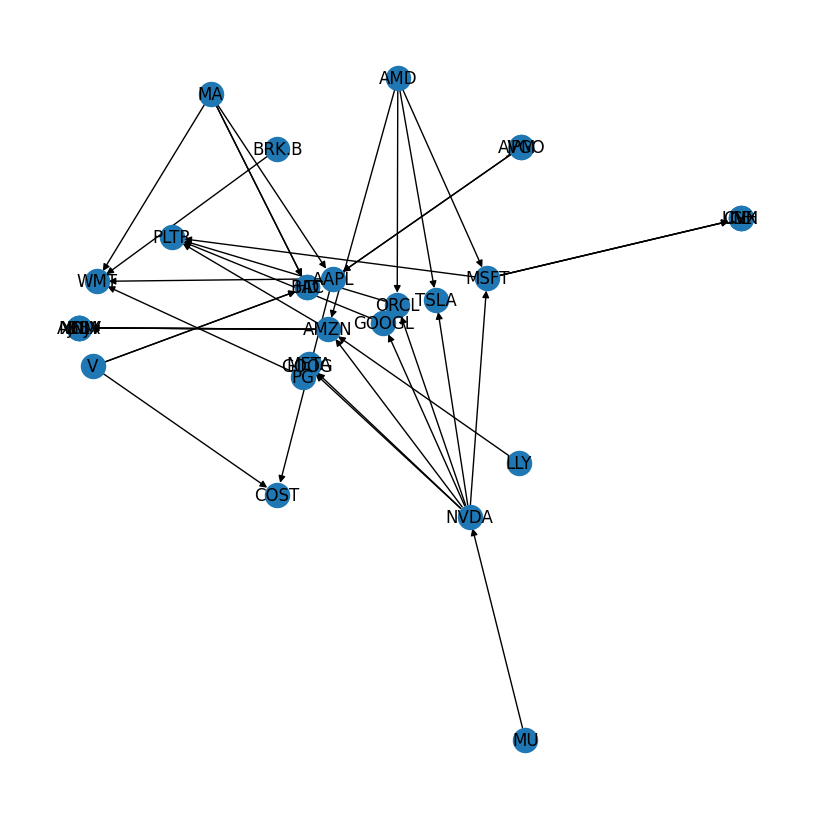

In [4]:
plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout, with_labels=True)

# Actividad


In [ ]:
def safe_katz_centrality(G, alpha=0.5, step=0.01):
    while alpha > 0:
        try:
            return nx.katz_centrality(G, alpha=alpha), alpha
        except Exception:
            alpha -= step

    raise ValueError("Katz centrality did not converge for any positive alpha.")

deg_centralidades = nx.degree_centrality(G1)
eig_centralidades = nx.eigenvector_centrality(G1)
katz_centralidades, katz_alpha = safe_katz_centrality(G1, alpha=0.1)
print(f"Convergio con un alpha={katz_alpha:.4f}")
pg_centralidades = nx.pagerank(G1)
hubs_centralidades, auth_centralidades = nx.hits(G1)
clos_centralidades = nx.closeness_centrality(G1)
btw_centralidades = nx.betweenness_centrality(G1)


def sum1_dict(d):
    s = sum(d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)
katz_centralidades = sum1_dict(katz_centralidades)
pg_centralidades = sum1_dict(pg_centralidades)
hubs_centralidades = sum1_dict(hubs_centralidades)
auth_centralidades = sum1_dict(auth_centralidades)
clos_centralidades = sum1_dict(clos_centralidades)
btw_centralidades = sum1_dict(btw_centralidades)


eig_sizes = np.array([eig_centralidades[n] for n in G1])
deg_colors = np.array([deg_centralidades[i] for i in G1])
pg_sizes = np.array([pg_centralidades[n] for n in G1])
katz_colors = np.array([katz_centralidades[i] for i in G1])
hubs_colors = np.array([hubs_centralidades[i] for i in G1])
auth_colors = np.array([auth_centralidades[i] for i in G1])
clos_colors = np.array([clos_centralidades[i] for i in G1])
btw_colors = np.array([btw_centralidades[i] for i in G1])

metrics = {
    "Degree": np.asarray(deg_colors, dtype=float),
    "Eigenvector": np.asarray(eig_sizes, dtype=float),
    "Katz": np.asarray(katz_colors, dtype=float),
    "PageRank": np.asarray(pg_sizes, dtype=float),
    "Hubs": np.asarray(hubs_colors, dtype=float),
    "Authorities": np.asarray(auth_colors, dtype=float),
    "Closeness": np.asarray(clos_colors, dtype=float),
    "Betweenness": np.asarray(btw_colors, dtype=float),
}

In [ ]:
k = 10

top_deg = [n for n, v in sorted(
    deg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_eig = [n for n, v in sorted(
    eig_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_katz = [n for n, v in sorted(
    katz_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_pg = [n for n, v in sorted(
    pg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_hubs = [n for n, v in sorted(
    hubs_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_auth = [n for n, v in sorted(
    auth_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_clos = [n for n, v in sorted(
    clos_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_btw = [n for n, v in sorted(
    btw_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

In [ ]:
# plot

def plot_network(
    G,
    metrics,
    metric="Degree",
    topk=10,
    largest_first=True,
    layout="kamada_kawai",
    colorscale="Turbo",
    renderer="vscode",   # or "notebook_connected"
    interactive=False,   # default static
):
    nodes = list(G.nodes())
    N = len(nodes)

    # Validate and normalize metrics
    m = {}
    for name, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{name}' has length {len(a)} but graph has {N} nodes.")
        m[name] = a

    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    # Fixed layout
    pos = nx.spring_layout(G, seed=7) if layout == "spring" else nx.kamada_kawai_layout(G)

    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    # Edges
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    global_max = max(arr.max() for arr in m.values())

    # Hover with all metrics for each node
    all_hover = []
    metric_order = list(m.keys())
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>"]
        for metric_name in metric_order:
            lines.append(f"{metric_name}: {m[metric_name][i]:.4f}")
        all_hover.append("<br>".join(lines))

    def topk_mask(vals, k, largest=True):
        k = max(1, min(int(k), len(vals)))
        idx = np.argsort(vals)
        pick = idx[-k:] if largest else idx[:k]
        mask = np.zeros(len(vals), dtype=bool)
        mask[pick] = True
        return mask

    def build_fig(metric_name, k, largest):
        vals = m[metric_name]
        mask = topk_mask(vals, k, largest)

        vmin, vmax = vals.min(), vals.max()
        sizes = 16 + 34 * (vals - vmin) / (vmax - vmin + 1e-12)
        order_txt = "largest to smallest" if largest else "smallest to largest"

        fig = go.Figure()

        # edges
        fig.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode="lines",
            line=dict(width=0.8, color="rgba(95,110,130,0.35)"),
            hoverinfo="none", showlegend=False
        ))

        # non-top-k
        fig.add_trace(go.Scatter(
            x=node_x[~mask], y=node_y[~mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if not keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#7A8797"),
            hovertext=[h for h, keep in zip(all_hover, mask) if not keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[~mask],
                color="#D9DEE5",
                opacity=0.45,
                line=dict(width=1.8, color="white"),
            ),
            showlegend=False
        ))

        # top-k
        fig.add_trace(go.Scatter(
            x=node_x[mask], y=node_y[mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#1F2937"),
            hovertext=[h for h, keep in zip(all_hover, mask) if keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[mask],
                color=vals[mask],
                colorscale=colorscale,
                cmin=0,
                cmax=global_max,
                opacity=0.98,
                line=dict(width=2.2, color="white"),
                colorbar=dict(
                    title=dict(text=metric_name, side="right", font=dict(family="Helvetica", size=13)),
                    thickness=36,
                    len=0.72,
                    y=0.5,
                    x=1.02,
                    outlinewidth=0,
                    borderwidth=0,
                    bgcolor="rgba(0,0,0,0)",
                    tickfont=dict(family="Helvetica", size=11),
                )
            ),
            showlegend=False
        ))

        fig.update_layout(
            title=dict(
                text=f"<b>Star Wars: Episode II - Attack of the Clones</b><br>Top {k} by {metric_name} from {order_txt}",
                font=dict(family="Helvetica", size=24, color="#111827")
            ),
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Helvetica", size=12, color="#334155"),
            margin=dict(l=10, r=130, t=90, b=10),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            height=740,
            dragmode="pan",
        )
        return fig

    # Static by default
    if not interactive:
        fig = build_fig(metric, max(1, min(int(topk), N)), largest_first)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    # Interactive controls
    metric_dd = widgets.Dropdown(
        options=list(m.keys()),
        value=metric,
        description="Metric:",
        layout=widgets.Layout(width="260px")
    )
    k_slider = widgets.IntSlider(
        value=max(1, min(int(topk), N)),
        min=1, max=N, step=1,
        description="Top k:",
        layout=widgets.Layout(width="340px")
    )
    order_btn = widgets.ToggleButtons(
        options=[("Largest first", True), ("Smallest first", False)],
        value=largest_first,
        description="Order:",
        layout=widgets.Layout(width="430px")
    )

    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, k_slider.value, order_btn.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    k_slider.observe(redraw, names="value")
    order_btn.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_dd, k_slider]), order_btn, out]))
    redraw()


In [ ]:
from IPython.display import clear_output
clear_output(wait=True)


In [ ]:
# tabla

def tabla(top_pos, digits):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "Degree": [deg_centralidades[n] for n in top_pos],
            "Eigenvector": [eig_centralidades[n] for n in top_pos],
            "Katz": [katz_centralidades[n] for n in top_pos],
            "PageRank": [pg_centralidades[n] for n in top_pos],
            "Hubs": [hubs_centralidades[n] for n in top_pos],
            "Authorities": [auth_centralidades[n] for n in top_pos],
            "Closeness": [clos_centralidades[n] for n in top_pos],
            "Betweenness": [btw_centralidades[n] for n in top_pos],
        })
        .reset_index(drop=True)
    )


    display(
        df.style.format(
            {
                "Eigenvector": f"{{:.{digits}f}}",
                "Degree": f"{{:.{digits}f}}",
                "PageRank": f"{{:.{digits}f}}",
                "Katz": f"{{:.{digits}f}}",
                "Hubs": f"{{:.{digits}f}}",
                "Authorities": f"{{:.{digits}f}}",
                "Closeness": f"{{:.{digits}f}}",
                "Betweenness": f"{{:.{digits}f}}",
            }
        )
    )
    return df

In [ ]:
# ego

def plot_ego(
    G,
    center,
    metrics,
    metric="Degree",
    radius=2,
    max_radius_user=4,
    layout="kamada_kawai",
    seed=7,
    renderer="vscode",
    interactive=False,   # default = static
):
    if center not in G:
        raise ValueError(f"{center!r} is not in graph")

    nodes = list(G.nodes())
    N = len(nodes)

    m = {}
    for k, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{k}' has length {len(a)} but graph has {N} nodes.")
        m[k] = a
    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    all_dist = nx.single_source_shortest_path_length(G, center)
    max_available = max(all_dist.values()) if all_dist else 0
    max_r = int(max(0, min(max_radius_user, max_available)))

    pos = nx.spring_layout(G, seed=seed, iterations=300) if layout == "spring" else nx.kamada_kawai_layout(G)
    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    ex, ey = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ex += [x0, x1, None]
        ey += [y0, y1, None]

    dist = nx.single_source_shortest_path_length(G, center, cutoff=max_r)

    cmap = matplotlib.colormaps["Blues"]
    if max_r > 0:
        stops = np.linspace(0.95, 0.35, max_r + 1)
        center_color = mcolors.to_hex(cmap(stops[0]))
        blues_by_d = {d: mcolors.to_hex(cmap(stops[d])) for d in range(1, max_r + 1)}
    else:
        center_color = mcolors.to_hex(cmap(0.95))
        blues_by_d = {}
    gray_out = "rgba(165,165,165,0.60)"

    metric_names = list(m.keys())
    hover_all = []
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>", f"dist({center})={all_dist.get(n,'∞')}"]
        lines += [f"{mk}: {m[mk][i]:.4f}" for mk in metric_names]
        hover_all.append("<br>".join(lines))

    def make_sizes(metric_name):
        vals = m[metric_name]
        vmin, vmax = vals.min(), vals.max()
        z = (vals - vmin) / (vmax - vmin + 1e-12)
        s = 14 + 20 * z
        return np.array([34 if n == center else float(si) for n, si in zip(nodes, s)])

    def make_title(r):
        SG = nx.ego_graph(G, center, radius=r)
        nn, ne = SG.number_of_nodes(), SG.number_of_edges()
        dens = nx.density(SG) if nn > 1 else 0.0
        cum = [len(nx.ego_graph(G, center, radius=d).nodes()) for d in range(r + 1)]
        neigh = [cum[d] - cum[d - 1] for d in range(1, r + 1)]
        return (
            f"<span style='font-size:22px; font-family:Helvetica; color:#1F2937;'><b>Nodo {center}</b> · radio {r}</span><br>"
            f"<span style='font-size:13px; color:#4B5563;'>Nodos <b>{nn}</b> · Aristas <b>{ne}</b> · Densidad <b>{dens:.3f}</b></span><br>"
            f"<span style='font-size:12px; color:#6B7280;'>Vecinos por distancia: <b>{neigh}</b></span>"
        )

    def build_fig(metric_name, r):
        r = int(max(0, min(r, max_r)))
        sizes = make_sizes(metric_name)

        colors, opac = [], []
        for n in nodes:
            d = dist.get(n, None)
            if n == center:
                colors.append(center_color); opac.append(1.0)
            elif d is not None and d <= r and d >= 1:
                colors.append(blues_by_d[d]); opac.append(0.96)
            else:
                colors.append(gray_out); opac.append(0.55)

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=ex, y=ey, mode="lines", line=dict(width=0.8, color="rgba(70,80,100,0.20)"), hoverinfo="none", showlegend=False))
        fig.add_trace(go.Scatter(
            x=node_x, y=node_y, mode="markers",
            hovertext=hover_all, hoverinfo="text",
            marker=dict(size=sizes, color=colors, opacity=opac, line=dict(width=2.0, color="white")),
            showlegend=False
        ))
        cx, cy = pos[center]
        fig.add_trace(go.Scatter(x=[cx], y=[cy], mode="text", text=[str(center)], textposition="top center",
                                 textfont=dict(size=20, color="#1F2937", family="Helvetica"), hoverinfo="skip", showlegend=False))
        fig.update_layout(
            title=make_title(r), template="simple_white",
            paper_bgcolor="#FFFFFF", plot_bgcolor="#FFFFFF",
            font=dict(family="Helvetica", size=13, color="#1F2937"),
            height=780, margin=dict(l=20, r=20, t=95, b=20),
            xaxis=dict(visible=False), yaxis=dict(visible=False), dragmode="pan"
        )
        return fig

    if not interactive:
        fig = build_fig(metric, radius)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    metric_dd = widgets.Dropdown(options=list(m.keys()), value=metric, description="Metric:", layout=widgets.Layout(width="260px"))
    r_slider = widgets.IntSlider(value=max(0, min(int(radius), max_r)), min=0, max=max_r, step=1, description="Radius:", layout=widgets.Layout(width="340px"))
    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, r_slider.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    r_slider.observe(redraw, names="value")
    display(widgets.VBox([widgets.HBox([metric_dd, r_slider]), out]))
    redraw()


## Grafica interactiva

In [ ]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, interactive=True)

In [ ]:
plot_ego(G1, center='OBI-WAN', metrics=metrics, interactive=True, max_radius_user=6)

## Top Grado

In [ ]:
df_top_deg = tabla(top_deg, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="Degree", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(deg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Degree", max_radius_user=6)

## Top Eigenvector

In [ ]:
df_top_deg = tabla(top_eig, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="Eigenvector", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(eig_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Eigenvector", max_radius_user=6)

## Top Katz

In [ ]:
df_top_deg = tabla(top_katz, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="Katz", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(katz_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Katz", max_radius_user=6)

## Top PageRank

In [ ]:
df_top_deg = tabla(top_pg, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(pg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="PageRank", max_radius_user=6)

## Top Hubs

In [ ]:
df_top_deg = tabla(top_hubs, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="Hubs", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(hubs_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Hubs", max_radius_user=6)

## Top Autoridad

In [ ]:
df_top_deg = tabla(top_auth, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="Authorities", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(auth_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Authorities", max_radius_user=6)

## Top Cercania

In [ ]:
df_top_deg = tabla(top_clos, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="Closeness", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(clos_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Closeness", max_radius_user=6)

## Top Intermediacion

In [ ]:
df_top_deg = tabla(top_btw, digits=4)

In [ ]:
_ = plot_network(G1, metrics, metric="Betweenness", topk=10, largest_first=True)

In [ ]:
maxpos_node, maxpos_val = max(btw_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Betweenness", max_radius_user=6)

# Interpretacion

En ambas redes, realiza un análisis: ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos (a los que apunta y los que lo apuntan)? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado, de eigenvector, de Katz y PageRank? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos (a los que apunta y los que lo apuntan)?
### Actividad

Responde: ¿hay similitud con los resultados de la centralidad de hubs o de autoridad? ¿A qué crees que se deba?

### Actividad

Responde, ¿hay cambios sustanciales de los nodos en sus distintos roles (de autoridad y de concentrador)? ¿O están rankeados similarmente en ambos roles? ¿Hay nodos que tengan una diferencia de al menos 10 lugares en su ranking como autoridad y como concentrador? ¿Cuál es el mayor diferencia? ¿A qué crees que se deba?

¿Hay cambios sustanciales con respecto a la centralidad de eigenvector?

# Interpretacion

Se interpretan las diferencias entre las centralidades de grado, eigenvector, Katz y PageRank. Se analizan los vértices que tienen una mayor diferencia entre estas centralidades y se discute su significado en el contexto de la red de colaboración. Se examinan los vecinos de estos vértices para entender cómo su posición en la red afecta su centralidad y cómo esto se relaciona con su papel como investigadores en la red.

Que converja con un $\alpha=1$ sugiere que la red, como sistema de “influencia por cadenas”, no tiene un nucleo denso que haga explotar la importancia al contar caminos largos. Comparado con las redes donde convergia con $\alpha$ de $0.08$–$0.09$, aqui se puede permitir que los caminos largos pesen mas sin inestabilidad numérica, por la estructura de dos componentes y sin un supernucleo que este dentro de un subconjunto.

node	Degree	Eigenvector	Katz	PageRank  
3	AAPL	0.0676	0.0000	0.0083	0.0681  
4	WMT_	0.0541	0.0000	0.0072	0.0565  
5	MA__	0.0541	0.0000	0.0078	0.0519  

Podemos ver que hay top nodos como AAPL, WMT y MA que estan en el nucleo de su componente y no tienen peso en la centralidad de eigenvector, porque en eigenvector solo tienen los de la componente mas grande (o de la que tenga un espectro mas grande) y estos 3 nodos son muy importantes en su componente.  
En todas AMZN y NVDA y MSFT son los que tienen el peso mas grande en todos los tipos de centralidad, esto porque estan en la red mas grande y son los mas conectados.

# Apendice: $\text{degree} - \text{eigenvector}$

Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.



Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.


## Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


## **!!!! Solo los componentes de la subred mas grande tienen eigenvector!!!** 

## Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**ORCL solo se conecta con otras 3 empresas, pero por sus vecinos la componente mas grande de la red se completa en 3 pasos**

## Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Aunque AAPL forme un grafo mas denso que AMD, AAPL esta en la segunda componente, entonces su diferencia es grande. El nodo que forma subredes mas densas de la componente mas grande es AMZN**

## Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**El que tiene mas diferencia de sus las coapariciones en las que aparece es Obi-Wan, es el que, en comparacion, sus coapariciones son menos significativas en relacion al total de sus coapariciones, porque sus vecinos casi no salen con mas**
